In [2]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
import copy
import h5py
# print(Path.cwd()) # Check current path

### Configurations, Probabilities, and Moments

In [8]:
def all_configurations(n):
    """
    Return Sigma with shape (2^n, n), entries in {-1, +1}.
    Row idx corresponds to configuration index idx.
    Least Significant Bit corresponds to spin/node 0.
    """
    n_states = 1 << n
    Sigma = np.empty((n_states, n), dtype=np.int8)

    for idx in range(n_states):
        for j in range(n):
            Sigma[idx, j] = 1 if ((idx >> j) & 1) else -1

    return Sigma


def log_prob_config(x, beta, edges, edge_weights):
    """
    log unnormalized probability for one configuration.
    Assumes edges are 0-based.
    """
    s = 0.0

    for (i, j), w in zip(edges, edge_weights):
        s += w * float(x[i]) * float(x[j])

    return beta * s


def true_moments(Sigma, beta, edges, edge_weights):
    """
    Computes:
    - p_unnorm: unnormalized probabilities
    - Z       : partition function
    - mean    : true mean vector
    - cov     : true covariance matrix
    """

    Sigma = np.asarray(Sigma, dtype=np.int8)

    n_configs, n = Sigma.shape

    log_p = np.empty(n_configs, dtype=float)

    for l in range(n_configs):
        log_p[l] = log_prob_config(Sigma[l, :], beta, edges, edge_weights)

    # Log-sum-exp trick
    log_p_max = np.max(log_p)
    log_Z = log_p_max + np.log(np.sum(np.exp(log_p - log_p_max)))
    Z = np.exp(log_Z)

    p_unnorm = np.exp(log_p)
    p_norm = np.exp(log_p - log_Z)

    # Mean
    mean = np.sum(Sigma * p_norm[:, None], axis=0)

    # Second moment E[xx^T]
    M2 = (Sigma.T * p_norm) @ Sigma

    # Covariance
    cov = M2 - np.outer(mean, mean)

    return p_unnorm, Z, mean, cov


def empirical_moments(samples):
    freqs = samples[:, 0]
    spins = samples[:, 1:]

    w = freqs / np.sum(freqs)

    mean = spins.T @ w
    cov = (spins.T * w) @ spins - np.outer(mean, mean)

    return mean, cov


def config_to_index(sigma):
    idx = 0
    for j, s in enumerate(sigma):
        if s == 1:
            idx |= (1 << j)
    return idx

### Graph Topology

Generate Graph Edges

In [9]:
def generate_lattice_graph(rows, cols):
    """
    Generates edges as tuples for a lattice graph.
    """
    edges = []

    for r in range(rows):
        for c in range(cols):
            node = r * cols + c

            # Connect to right neighbor
            if c < cols - 1:
                right = node + 1
                edges.append((node, right))

            # Connect to bottom neighbor
            if r < rows - 1:
                below = node + cols
                edges.append((node, below))

    return edges

Generate Sequences

In [10]:
def lattice_skip_sequence(n):
    assert n >= 2, "Use n >= 2"

    seq = []

    # Pass 1
    for r in range(n):
        startc = 0 if r % 2 == 0 else 1
        for c in range(startc, n, 2):
            seq.append(r * n + c)

    # Pass 2
    for r in range(n):
        startc = 1 if r % 2 == 0 else 0
        for c in range(startc, n, 2):
            seq.append(r * n + c)

    return seq


def idx(r, c, n):
    return r * n + c

def lattice_diagonal_sequence(n):
    assert n >= 2, "Use n >= 2"

    # Build diagonals keyed by d = c - r
    diags = {}
    for d in range(-(n - 1), n):
        v = []

        rmin = max(0, -d)
        rmax = min(n - 1, n - 1 - d)

        for r in range(rmin, rmax + 1):
            c = r + d
            v.append(idx(r, c, n))

        diags[d] = v

    # ---- Main diagonal: center, then skip-one outward (LEFT FIRST) ----
    main = diags[0]

    # left-of-center if even
    mid = (n - 1) // 2

    picked = [main[mid]]

    for step in range(2, n, 2):
        l = mid - step
        r = mid + step

        if l >= 0:
            picked.append(main[l])
        if r < n:
            picked.append(main[r])

    # Append remaining main-diagonal nodes in natural order
    for x in main:
        if x not in picked:
            picked.append(x)

    seq = picked.copy()

    # ---- Upper triangle (skip one diagonal, pick next) ----
    for d in range(2, n, 2):
        seq.extend(diags[d])

    for d in range(1, n, 2):
        seq.extend(diags[d])

    # ---- Lower triangle (skip one diagonal, pick next) ----
    for d in range(-2, -n, -2):
        seq.extend(diags[d])

    for d in range(-1, -n, -2):
        seq.extend(diags[d])

    return seq


def parent_count_if_next(adj, selected, candidate):
    """
    Number of autoregressive parents candidate would have if selected next.

    selected[j] is True for already selected nodes.
    The parents are selected nodes adjacent to the connected component
    containing candidate in the subgraph induced by unselected nodes.
    """
    n = len(adj)

    # Find candidate's connected component among currently unselected nodes.
    component = set()
    stack = [candidate]

    while stack:
        node = stack.pop()

        if node in component:
            continue

        component.add(node)

        for neighbor in adj[node]:
            if not selected[neighbor] and neighbor not in component:
                stack.append(neighbor)

    # Selected boundary nodes are the effective parents.
    parents = set()

    for node in component:
        for neighbor in adj[node]:
            if selected[neighbor]:
                parents.add(neighbor)

    return len(parents)


def greedy_frontier_sequence(edges, n):
    """
    Greedy autoregressive ordering with one-step lookahead.
    """

    # Build adjacency list.
    adj = [[] for _ in range(n)]

    for u, v in edges:
        adj[u].append(v)
        adj[v].append(u)

    sequence = []
    selected = [False] * n
    realized_sizes = []

    while len(sequence) < n:
        best_node = None
        best_current_size = None
        best_score = None

        for candidate in range(n):
            if selected[candidate]:
                continue

            # Parent count if candidate is selected now.
            current_size = parent_count_if_next(adj, selected, candidate)

            # Temporarily select candidate.
            selected[candidate] = True

            prospective_sizes = []

            for other in range(n):
                if not selected[other]:
                    prospective_sizes.append(parent_count_if_next(adj, selected, other))

            selected[candidate] = False

            realized_max = max(realized_sizes, default=0)
            prospective_max = max(prospective_sizes, default=0)

            projected_max = max(realized_max, current_size, prospective_max)

            projected_count = (
                sum(size == projected_max for size in realized_sizes)
                + int(current_size == projected_max)
                + sum(size == projected_max for size in prospective_sizes)
            )

            future_max = prospective_max

            future_count = sum(size == future_max for size in prospective_sizes)

            # Same lexicographic priorities as the Julia version.
            score = (projected_max, projected_count, future_max, future_count, sum(prospective_sizes), current_size, candidate)

            if best_score is None or score < best_score:
                best_score = score
                best_node = candidate
                best_current_size = current_size

        sequence.append(best_node)
        realized_sizes.append(best_current_size)
        selected[best_node] = True

    return sequence

Defining Parent Set

In [11]:
def build_autoregressive_parents(edges, sequence):
    """
    Returns a dictionary of nodes and parent nodes, for an autoregressive model.

    This algorithm visits each node sequentially as per the input sequence, 
    node j is denoted as a parent node to i if there exists a path  
    (i,k1),(k1,k2),...,(km,j), with each kl=sequence[i-1], connecting i to j, and
    kl !∊ parent(i). 
    """

    # Build adjacency list
    adj = {}
    for u, v in edges:
        adj.setdefault(u, []).append(v)
        adj.setdefault(v, []).append(u)

    parent_dict = {}

    def has_valid_path(parent, child, blocked):
        visited = set()
        stack = [parent]

        while stack:
            node = stack.pop()

            if node == child:
                return True

            visited.add(node)

            for neighbor in adj[node]:
                if neighbor not in visited and neighbor not in blocked:
                    stack.append(neighbor)

        return False

    for i, node in enumerate(sequence):
        previous_nodes = sequence[:i]
        parents = []

        for candidate in previous_nodes:
            blocked = set(previous_nodes)
            blocked.remove(candidate)  # Only allow the candidate to walk through

            if has_valid_path(candidate, node, blocked):
                parents.append(candidate)

        parent_dict[node] = parents

    return parent_dict

### Generate Samples

In [12]:
def compress_samples(samples):
    unique_configs, counts = np.unique(samples, axis=0, return_counts=True)
    compressed = np.hstack((counts[:, None], unique_configs))

    return compressed.astype(np.int64)

In [13]:
def generate_training_samples(p, Z, m, n, rng=None):
    """
    Generate samples from an unnormalized probability vector.

    Returns an array with shape (n_obs, n + 1):
    - column 0: count for each observed state
    - columns 1: spin values in {-1, +1}
    """

    if rng is None:
        rng = np.random.default_rng()

    n_states = 1 << n
    assert len(p) == n_states, "length of p must equal 2^n"
    assert Z > 0, "Z must be positive"

    # Normalize
    prob = np.asarray(p, dtype=float) / float(Z)

    # Guard against rounding drift
    prob = prob / prob.sum()

    # Sample state indices, 0-based
    idxs = rng.choice(n_states, size=m, replace=True, p=prob)

    # Count occurrences of each state
    counts = np.bincount(idxs, minlength=n_states)

    # Keep only observed states
    observed = np.nonzero(counts)[0]
    n_obs = len(observed)

    samples = np.empty((n_obs, n + 1), dtype=int)

    samples[:, 0] = counts[observed]

    for row, state in enumerate(observed):
        for j in range(n):
            samples[row, j + 1] = 1 if ((state >> j) & 1) == 1 else -1

    return samples

In [14]:
def generate_test_samples_local(O, parents_dict, theta0, networks, m, q=2, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    n = len(O)

    x = np.ones((m, n), dtype=int)
    
    with torch.no_grad():
        for pos, node in enumerate(O):  

            if pos == 0:
                theta = theta0.detach().cpu().item()

                weight_pos = np.exp(theta)  # p(x_i = 1)
                weight_neg = np.exp(-theta) # p(x_i = -1)

            else:
                parents = parents_dict[node]
                parent_cols = np.array(parents, dtype=int)

                sigma_par = torch.as_tensor(x[:, parent_cols], dtype=torch.float32)

                mlp_node = networks[node]
                nn_output = mlp_node(sigma_par).detach().cpu().numpy()

                # For x_i = +1
                phi_minus_pos = -1 / q
                phi_plus_pos = 1 - 1 / q

                # For x_i = -1
                phi_minus_neg = 1 - 1 / q
                phi_plus_neg = -1 / q

                weight_pos = np.exp(phi_minus_pos * nn_output[:, 0]
                                    + phi_plus_pos * nn_output[:, 1])

                weight_neg = np.exp(phi_minus_neg * nn_output[:, 0]
                                    + phi_plus_neg * nn_output[:, 1])
                
            prob_pos = weight_pos / (weight_pos + weight_neg)

            make_negative = rng.random(m) >= prob_pos
            x[make_negative, node] = -1

    comb, count = np.unique(x, axis=0, return_counts=True)
    X = np.column_stack((count,comb))
    
    return X


def generate_test_samples_global(O, parents_dict, network, m, q=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    n = len(O)

    x = np.ones((m, n), dtype=int)

    with torch.no_grad():
        for pos, node in enumerate(O):

            sigma_masked = torch.zeros((m, n), dtype=torch.float32)
            parent_mask = torch.zeros((m, n), dtype=torch.float32)

            parents = parents_dict[node]

            if len(parents) > 0:
                parent_cols = np.array(parents, dtype=int)
                sigma_masked[:, parent_cols] = torch.as_tensor(
                    x[:, parent_cols],
                    dtype=torch.float32,
                )
                parent_mask[:, parent_cols] = 1.0

            node_onehot = torch.zeros((m, n), dtype=torch.float32)
            node_onehot[:, node] = 1.0

            x_in = torch.cat(
                [sigma_masked, parent_mask, node_onehot],
                dim=1,
            )

            nn_output = network(x_in).detach().cpu().numpy()

            phi_minus_pos = -1 / q
            phi_plus_pos = 1 - 1 / q

            phi_minus_neg = 1 - 1 / q
            phi_plus_neg = -1 / q

            weight_pos = np.exp(phi_minus_pos * nn_output[:, 0]
                                + phi_plus_pos * nn_output[:, 1])

            weight_neg = np.exp(phi_minus_neg * nn_output[:, 0]
                                + phi_plus_neg * nn_output[:, 1])

            prob_pos = weight_pos / (weight_pos + weight_neg)

            make_negative = rng.random(m) >= prob_pos
            x[make_negative, node] = -1

    comb, count = np.unique(x, axis=0, return_counts=True)
    X = np.column_stack((count, comb))

    return X

### Log-Probability Computation

In [15]:
def log_q_configurations(O, parents_dict, theta0, networks, configurations, mode="local"):
    """Return log q_theta(sigma) for every row of configurations."""

    if mode not in {"local", "global"}:
        raise ValueError("mode must be 'local' or 'global'.")

    configurations = np.asarray(configurations)
    n_obs, n = configurations.shape
    log_q = np.zeros(n_obs)

    with torch.no_grad():
        for pos, node_raw in enumerate(O):
            node = int(node_raw)
            sigma_i = configurations[:, node]

            if mode == "local":
                if pos == 0:
                    if theta0 is None:
                        raise ValueError("theta0 is required for mode='local'.")

                    theta = float(theta0.detach().item()) if torch.is_tensor(theta0) else float(theta0)
                    logit_difference = np.full(n_obs, 2.0 * theta)
                else:
                    parents = np.asarray(parents_dict[node], dtype=int)
                    sigma_parents = torch.as_tensor(configurations[:, parents], dtype=torch.float32)

                    output = networks[node](sigma_parents).detach().numpy()
                    logit_difference = output[:, 1] - output[:, 0]

            else:
                parents = np.asarray(parents_dict[node], dtype=int)

                sigma_masked = torch.zeros((n_obs, n), dtype=torch.float32)
                parent_mask = torch.zeros((n_obs, n), dtype=torch.float32)

                if len(parents) > 0:
                    sigma_masked[:, parents] = torch.as_tensor(
                        configurations[:, parents], dtype=torch.float32
                    )
                    parent_mask[:, parents] = 1.0

                node_onehot = torch.zeros((n_obs, n), dtype=torch.float32)
                node_onehot[:, node] = 1.0

                network_input = torch.cat(
                    [sigma_masked, parent_mask, node_onehot], dim=1
                )
                output = networks(network_input).detach().numpy()
                logit_difference = output[:, 1] - output[:, 0]

            log_q += np.where(
                sigma_i == 1,
                -np.logaddexp(0.0, -logit_difference),
                -np.logaddexp(0.0, logit_difference),
            )

    return log_q

### Sampling Error Computation

Heldout-NLL

In [16]:
def heldout_nll_error(O, parents_dict, theta0, networks, heldout_samples,
                      mode="local", per_spin=True):
    """Estimate -E_p[log q_theta(X)] from the fixed held-out sample."""

    heldout_samples = np.asarray(heldout_samples)
    counts = heldout_samples[:, 0].astype(float)
    configurations = heldout_samples[:, 1:].astype(float)
    weights = counts / counts.sum()

    log_q = log_q_configurations(
        O, parents_dict, theta0, networks, configurations, mode=mode
    )

    nll = -np.dot(weights, log_q)
    return nll / len(O) if per_spin else nll

MMD computation

In [17]:
def _draw_from_compressed(samples, max_samples, rng):
    configurations = samples[:, 1:].astype(float)
    counts = samples[:, 0].astype(float)
    weights = counts / counts.sum()
    total = int(round(counts.sum()))

    if total <= max_samples:
        return np.repeat(configurations, counts.astype(int), axis=0)

    indices = rng.choice(
        len(configurations), size=max_samples, replace=True, p=weights
    )
    return configurations[indices]


def mmd_rbf(samples_p, samples_q, sigma=None, max_samples=2000, rng=None):
    """
    Biased empirical MMD using
        k(x,y) = exp(-||x-y||^2 / (2 sigma^2)).
    """

    if rng is None:
        rng = np.random.default_rng()

    x = _draw_from_compressed(samples_p, max_samples, rng)
    y = _draw_from_compressed(samples_q, max_samples, rng)

    if sigma is None:
        reference_size = min(len(x), 1000)
        reference = x[:reference_size]

        squared_distances = (
            np.sum(reference**2, axis=1)[:, None]
            + np.sum(reference**2, axis=1)[None, :]
            - 2.0 * reference @ reference.T
        )

        upper = squared_distances[np.triu_indices(reference_size, k=1)]
        positive = upper[upper > 0]

        sigma = np.sqrt(np.median(positive)) if len(positive) > 0 else 1.0

    def kernel(a, b):
        squared_distances = (
            np.sum(a**2, axis=1)[:, None]
            + np.sum(b**2, axis=1)[None, :]
            - 2.0 * a @ b.T
        )
        squared_distances = np.maximum(squared_distances, 0.0)

        return np.exp(-squared_distances / (2.0 * sigma**2))

    mmd_squared = (
        kernel(x, x).mean()
        + kernel(y, y).mean()
        - 2.0 * kernel(x, y).mean()
    )

    return np.sqrt(max(float(mmd_squared), 0.0))

In [18]:
def error_computation(
        n, m, beta, edges, edge_weights, O, parents_dict, gen_samples, networks,
        *, theta0=None, mode="local", rng=None, heldout_samples=None,
        compute_sampler_kl=False, compute_reverse_kl=False, per_spin=True,
        compute_magnetization=False, compute_empirical_tv=False,
        compute_mmd=False, mmd_sigma=None, mmd_max_samples=2000):

    """Compute errors for one compressed set of generated samples."""

    if rng is None:
        rng = np.random.default_rng()

    if mode not in {"local", "global"}:
        raise ValueError("mode must be 'local' or 'global'.")

    if n != len(O):
        raise ValueError(f"n={n}, but len(O)={len(O)}.")

    gen_samples = np.asarray(gen_samples)
    counts = gen_samples[:, 0].astype(float)
    configurations = gen_samples[:, 1:].astype(float)

    total = counts.sum()
    if not np.isclose(total, m):
        raise ValueError(
            f"Inconsistent sample count: m={m}, but sum(counts)={total}."
        )

    weights = counts / total

    requires_heldout = (
        compute_magnetization
        or compute_empirical_tv
        or compute_mmd
    )
    if requires_heldout and heldout_samples is None:
        raise ValueError(
            "heldout_samples are required for magnetization TV, "
            "empirical TV, and MMD."
        )

    # ---------- log q_theta on generated configurations ----------

    log_q_generated = None
    if compute_sampler_kl or compute_reverse_kl:
        log_q_generated = log_q_configurations(
            O, parents_dict, theta0, networks,
            configurations, mode=mode,
        )

    # ---------- KL(q_hat_Ms || q_theta) ----------

    sampler_kl = None
    if compute_sampler_kl:
        log_q_empirical = np.log(weights)

        sampler_kl = np.dot(
            weights,
            log_q_empirical - log_q_generated,
        )

        if per_spin:
            sampler_kl /= n

    # ---------- Reverse-KL surrogate ----------

    reverse_kl_surrogate = None
    if compute_reverse_kl:
        log_p_unnormalized = np.asarray([
            log_prob_config(sigma, beta, edges, edge_weights)
            for sigma in configurations
        ])

        reverse_kl_surrogate = np.dot(
            weights,
            log_q_generated - log_p_unnormalized,
        )

        if per_spin:
            reverse_kl_surrogate /= n

    # ---------- Magnetization-distribution TV ----------

    magnetization_tv_error = None
    if compute_magnetization:
        ref_counts = heldout_samples[:, 0].astype(float)
        ref_configurations = heldout_samples[:, 1:].astype(float)
        ref_weights = ref_counts / ref_counts.sum()

        possible_spin_sums = np.arange(-n, n + 1, 2)

        gen_spin_sums = configurations.sum(axis=1).astype(int)
        ref_spin_sums = ref_configurations.sum(axis=1).astype(int)

        p_gen = np.array([
            weights[gen_spin_sums == s].sum()
            for s in possible_spin_sums
        ])

        p_ref = np.array([
            ref_weights[ref_spin_sums == s].sum()
            for s in possible_spin_sums
        ])

        magnetization_tv_error = 0.5 * np.sum(
            np.abs(p_gen - p_ref)
        )

    # ---------- Empirical full-state TV ----------

    empirical_tv = None
    if compute_empirical_tv:
        probabilities_p = {
            tuple(row[1:].astype(int)):
            float(row[0]) / heldout_samples[:, 0].sum()
            for row in heldout_samples
        }

        probabilities_q = {
            tuple(row[1:].astype(int)):
            float(row[0]) / gen_samples[:, 0].sum()
            for row in gen_samples
        }

        support = probabilities_p.keys() | probabilities_q.keys()

        empirical_tv = 0.5 * sum(
            abs(
                probabilities_p.get(x, 0.0)
                - probabilities_q.get(x, 0.0)
            )
            for x in support
        )

    # ---------- MMD ----------

    mmd = None
    if compute_mmd:
        mmd = mmd_rbf(
            heldout_samples, gen_samples,
            sigma=mmd_sigma,
            max_samples=mmd_max_samples,
            rng=rng,
        )

    return {
        "sampler_kl": sampler_kl,
        "reverse_kl_surrogate": reverse_kl_surrogate,
        "magnetization_tv_error": magnetization_tv_error,
        "empirical_tv": empirical_tv,
        "mmd": mmd,
    }

In [19]:
def finite_sampling_error(
        m, O, beta, edges, edge_weights, parents_dict, networks,
        *, theta0=None, mode="local", rng=None, ntry=20,
        heldout_samples=None, compute_heldout_nll=False,
        compute_sampler_kl=False, compute_reverse_kl=False, per_spin=True,
        compute_empirical_tv=False, compute_magnetization=False,
        compute_mmd=False, mmd_sigma=None, mmd_max_samples=2000):

    """
    Average sampling-dependent errors over ntry generated sample sets.
    Held-out NLL is computed once for the learned model.
    """

    if rng is None:
        rng = np.random.default_rng()

    if mode not in {"local", "global"}:
        raise ValueError("mode must be 'local' or 'global'.")

    if ntry <= 0:
        raise ValueError("ntry must be positive.")

    n = len(O)

    requires_heldout = (
        compute_heldout_nll
        or compute_magnetization
        or compute_empirical_tv
        or compute_mmd
    )
    if requires_heldout and heldout_samples is None:
        raise ValueError(
            "heldout_samples are required for the requested metrics."
        )

    # ---------- Held-out NLL: compute once ----------

    heldout_nll = None
    if compute_heldout_nll:
        heldout_nll = heldout_nll_error(
            O, parents_dict, theta0, networks,
            heldout_samples,
            mode=mode,
            per_spin=per_spin,
        )

    # ---------- Sampling-dependent metrics ----------

    metric_flags = {
        "sampler_kl": compute_sampler_kl,
        "reverse_kl_surrogate": compute_reverse_kl,
        "magnetization_tv_error": compute_magnetization,
        "empirical_tv": compute_empirical_tv,
        "mmd": compute_mmd,
    }

    sums = {
        metric: 0.0
        for metric, enabled in metric_flags.items()
        if enabled
    }

    for _ in range(ntry):

        if mode == "local":
            gen_samples = generate_test_samples_local(
                O, parents_dict, theta0, networks, m, rng=rng
            )
        else:
            gen_samples = generate_test_samples_global(
                O, parents_dict, networks, m, rng=rng
            )

        errors = error_computation(
            n, m, beta, edges, edge_weights,
            O, parents_dict, gen_samples, networks,
            theta0=theta0,
            mode=mode,
            rng=rng,
            heldout_samples=heldout_samples,
            compute_sampler_kl=compute_sampler_kl,
            compute_reverse_kl=compute_reverse_kl,
            per_spin=per_spin,
            compute_magnetization=compute_magnetization,
            compute_empirical_tv=compute_empirical_tv,
            compute_mmd=compute_mmd,
            mmd_sigma=mmd_sigma,
            mmd_max_samples=mmd_max_samples,
        )

        for metric in sums:
            sums[metric] += errors[metric]

    results = {
        metric: sums[metric] / ntry if enabled else None
        for metric, enabled in metric_flags.items()
    }

    results["heldout_nll"] = heldout_nll

    return results

### neuRISE Learning - LOCAL 
Parameterize each conditional by a neural network

In [20]:
def make_mlp(input_dim, hidden_dim, output_dim=2, num_hidden_layers=2):
    layers = []
    d = input_dim

    for _ in range(num_hidden_layers):
        layers.append(torch.nn.Linear(d, hidden_dim))
        layers.append(torch.nn.ReLU())
        d = hidden_dim

    layers.append(torch.nn.Linear(d, output_dim))
    return torch.nn.Sequential(*layers)


In [21]:
def neuRISE_loss_local(node, m, samples, parents, theta0=None, mlp=None, q=2):

    counts = torch.as_tensor(samples[:, 0]) # Extract sample counts  
    sigma_i_np = samples[:, node + 1] # Extract sigma_i
    sigma_i = torch.as_tensor(sigma_i_np, dtype=torch.float32)

    if len(parents) == 0:
        loss = (1 / m) * torch.sum(counts * torch.exp(-theta0 * sigma_i))
    else:
        # Compute NN(parents)
        parent_cols = np.array(parents, dtype=int) + 1

        sigma_par = torch.as_tensor(samples[:, parent_cols], dtype=torch.float32)

        nn_output = mlp(sigma_par)

        # Compute centered indicators Phi(xi)
        phi_minus = torch.as_tensor(np.where(sigma_i_np == -1, 1 - 1/q, -1/q), dtype=torch.float32)
        phi_plus = torch.as_tensor(np.where(sigma_i_np == 1, 1 - 1/q, -1/q), dtype=torch.float32)

        # Compute the loss for variable i: exp(-Phi(xi)*NN(Neighbours(xi))
        loss = (1 / m) * torch.sum(counts * torch.exp(-phi_minus * nn_output[:, 0] 
                                                    -phi_plus * nn_output[:, 1]))

    return loss

In [22]:
def neuRISE_local(n, O, parents_dict, m, samples, hd, od, ep, lr, 
                  num_hidden_layers=2, patience=300, tol=1e-6, print_every=500):
    """
    Arguments:
    O              : ordering of nodes, 
    parents_dict   : dictionary node -> list of parents, 
    m, samples     : number of data samples, data samples
    hd, od, ep, lr : hidden dim, output dim, number of epochs, learning rate,
    n              : number of nodes
    """

    # --- First node ---
    first_node = O[0]
    theta0 = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)
    optimizer = optim.Adam([theta0], lr=lr) 

    best_loss = float("inf")
    best_theta0 = None
    stale = 0

    for epoch in range(ep):
        optimizer.zero_grad()
        loss = neuRISE_loss_local(first_node, m, samples, parents=[], theta0=theta0, q=od)
        loss.backward()
        optimizer.step()

        loss_val = loss.item()

        if best_loss - loss_val > tol:
            best_loss = loss_val
            best_theta0 = theta0.detach().clone()
            stale = 0
        else:
            stale += 1

        # if (epoch + 1) % print_every == 0 or epoch == 0 or epoch == ep - 1:
        #     print(
        #         f"epoch {epoch+1:5d}/{ep} | "
        #         f"loss = {loss_val:.6f} | "
        #         f"best = {best_loss:.6f}"
        #     )

        if stale >= patience:
            # print(
            #     f"Early stopping at epoch {epoch+1}, "
            #     f"best loss = {best_loss:.6f}"
            # )
            break

    theta0.data.copy_(best_theta0)


    # --- Define MLP for remaining nodes ---
    networks = {}

    for pos in range(1,n): # starting from the second sequence position
        node = O[pos]
        parents = parents_dict[node]
        input_dim = len(parents)

        mlp = make_mlp(input_dim, hd, od, num_hidden_layers)

        optimizer = optim.Adam(mlp.parameters(), lr=lr)
        
        best_loss = float("inf")
        best_state = copy.deepcopy(mlp.state_dict())
        stale = 0

        for epoch in range(ep):
            optimizer.zero_grad()
            loss = neuRISE_loss_local(node, m, samples, parents, mlp=mlp, q=od)
            loss.backward()
            optimizer.step()

            loss_val = loss.item()

            if best_loss - loss_val > tol:
                best_loss = loss_val
                best_state = copy.deepcopy(mlp.state_dict())
                stale = 0
            else:
                stale += 1

            # if (epoch + 1) % print_every == 0 or epoch == 0 or epoch == ep - 1:
            #     print(
            #         f"epoch {epoch+1:5d}/{ep} | "
            #         f"loss = {loss_val:.6f} | "
            #         f"best = {best_loss:.6f}"
            #     )

            if stale >= patience:
                # print(
                #     f"Early stopping at epoch {epoch+1}, "
                #     f"best loss = {best_loss:.6f}"
                # )
                break

        mlp.load_state_dict(best_state)
        networks[node] = mlp

    return theta0, networks

### neuRISE Learning - GLOBAL
Parameterize all conditionals by one neural network

In [23]:
def neuRISE_loss_global(O, samples, parents_dict, mlp, q=2, 
                        node_batch_size=None, rng=None):
    
    counts = torch.as_tensor(samples[:, 0], dtype=torch.float32)
    spins = torch.as_tensor(samples[:, 1:], dtype=torch.float32)

    n_obs = samples.shape[0]
    n_nodes = len(O)

    if rng is None:
        rng = np.random.default_rng()

    if node_batch_size is None or node_batch_size == n_nodes:
        pos_batch = np.arange(n_nodes)
    else:
        pos_batch = rng.choice(n_nodes, size=node_batch_size, replace=False)

    weights = counts / counts.sum()

    node_losses = []

    for pos in pos_batch:
        node = int(O[pos])

        sigma_i = spins[:, node]
        parents = np.asarray(parents_dict[node], dtype=int)

        sigma_masked = torch.zeros((n_obs, n_nodes), dtype=torch.float32)
        parent_mask = torch.zeros((n_obs, n_nodes), dtype=torch.float32)

        if len(parents) > 0:
            sigma_masked[:, parents] = spins[:, parents]
            parent_mask[:, parents] = 1.0

        node_onehot = torch.zeros((n_obs, n_nodes), dtype=torch.float32)
        node_onehot[:, node] = 1.0

        nn_output = mlp(torch.cat([sigma_masked, parent_mask, node_onehot], dim=1))
        phi_minus = torch.where(sigma_i == -1, 1.0 - 1.0 / q, -1.0 / q)
        phi_plus = torch.where(sigma_i == 1, 1.0 - 1.0 / q, -1.0 / q)

        node_losses.append(torch.sum(weights * torch.exp(
                    -phi_minus * nn_output[:, 0] - phi_plus * nn_output[:, 1]
                )))

    return torch.stack(node_losses).mean()

In [24]:
def neuRISE_global(n, O, parents_dict, samples, hd, od, ep, lr,
                   num_hidden_layers=2, node_batch_size=None, patience=5,
                   tol=1e-5, check_every=100, print_every=500, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    mlp = make_mlp(3 * n, hd, od, num_hidden_layers)
    optimizer = optim.Adam(mlp.parameters(), lr=lr)

    best_loss = float("inf")
    best_state = copy.deepcopy(mlp.state_dict())
    stale_checks = 0

    initial_loss = neuRISE_loss_global(
        O, samples, parents_dict, mlp, q=2,
        node_batch_size=None, rng=rng).item()
    print(f"initial full loss={initial_loss:.6f}")

    for epoch in range(ep):
        optimizer.zero_grad()

        loss = neuRISE_loss_global(
            O, samples, parents_dict, mlp, q=2,
            node_batch_size=node_batch_size, rng=rng,
        )

        loss.backward()

        should_check = (epoch + 1) % check_every == 0 or epoch == ep - 1

        if should_check:
            if node_batch_size is None:
                monitor_loss = loss.item()
            else:
                with torch.no_grad():
                    monitor_loss = neuRISE_loss_global(
                        O, samples, parents_dict, mlp, q=2,
                        node_batch_size=None, rng=rng,
                    ).item()

            if best_loss - monitor_loss > tol:
                best_loss = monitor_loss
                best_state = copy.deepcopy(mlp.state_dict())
                stale_checks = 0
            else:
                stale_checks += 1

            if (epoch + 1) % print_every == 0 or epoch == ep - 1:
                print(
                    f"epoch {epoch + 1:5d}/{ep} | "
                    f"batch loss={loss.item():.6f} | "
                    f"full loss={monitor_loss:.6f} | best={best_loss:.6f}"
                )

            if stale_checks >= patience:
                break

        optimizer.step()

    mlp.load_state_dict(best_state)
    return mlp

## Main--Learning and Sampling

In [ ]:
# --- Number of vertices ---
N = 100
# Number of vertices along each edge of the lattice
L = int(np.sqrt(N))

beta = 0.2
beta_tag = str(beta).replace(".", "")

# --- Range of data and generated samples ---
Ml_range = [500,1000, 5000, 10_000]
I = len(Ml_range)

Ms = 100_000

# --- Number of iterations ---
T = 10

# --- Define graph topology ---
edges = generate_lattice_graph(L, L)
edge_weights = np.ones(len(edges))

ordering_keys = ("sequential", "diagonal", "greedy") #"checkerboard", 

# --- Define sequences (nodes numbering start from 0) ---
seq = np.arange(N)
# seq_skip = lattice_skip_sequence(L)
seq_diag = lattice_diagonal_sequence(L)
seq_greedy = greedy_frontier_sequence(edges, N)

models = {
    "sequential": {
        "label": "Sequential",
        "seq": seq,
        "parents": build_autoregressive_parents(edges, seq),
    },
    # "checkerboard": {
    #     "label": "Checkerboard",
    #     "seq": seq_skip,
    #     "parents": build_autoregressive_parents(edges, seq_skip),
    # },
    "diagonal": {
        "label": "Diagonal",
        "seq": seq_diag,
        "parents": build_autoregressive_parents(edges, seq_diag),
    },
    "greedy": {
        "label": "Greedy",
        "seq": seq_greedy,
        "parents": build_autoregressive_parents(edges, seq_greedy),
    },
}

# --- Metrics ---
metrics = (
    "heldout_nll",
    "reverse_kl_surrogate",
    "magnetization_tv_error",
    "empirical_tv",
)

# ---- Store solutions and results ---
solutions = {
    ml: {
        key: [None] * T
        for key in ordering_keys
    }
    for ml in Ml_range
}

mean_errors = {
    key: {
        metric: np.full(I, np.nan, dtype=float)
        for metric in metrics
    }
    for key in ordering_keys
}

std_errors = {
    key: {
        metric: np.full(I, np.nan, dtype=float)
        for metric in metrics
    }
    for key in ordering_keys
}

all_trial_errors = {
    key: {
        metric: np.full((I, T), np.nan, dtype=float)
        for metric in metrics
    }
    for key in ordering_keys
}

results = {
    "trial_errors": all_trial_errors,
    "summary": {
        "mean": mean_errors,
        "std": std_errors,
    },
}   

# --- Load moment and samples ---
# moments_path = Path(f"Data/10x10/Data_10x10_Ferro_beta={beta_tag}.h5")

# with h5py.File(moments_path, "r") as f:
#     mean_true = f["mean_true"][()]
#     cov_true = f["cov_true"][()]

samples_path = Path(f"Data/10x10/Samples_10x10_M=200K_Ferro_beta={beta_tag}.csv")
data_samples = np.loadtxt(samples_path, delimiter=",").astype(np.int8)

# --- Reserve training and held-out samples ----
training_pool = data_samples[:-20_000]

heldout_raw = data_samples[-20_000:]
heldout_samples = compress_samples(heldout_raw)

# --- Neural Network Specifications ---
hidden_dim, num_hidden_layers, output_dim = 100, 2, 2
num_epochs, learning_rate = 2000, 1e-3
node_batch_size = None

# ---- Save Path ----
save_path = Path(f"Results/10x10/Results_10x10_Ferro_{beta_tag}_500.pt")
save_path.parent.mkdir(parents=True, exist_ok=True)

# ---- Main Loop ---
sampling_ntry = 20

for j, ml in enumerate(Ml_range):

    if ml > len(training_pool):
        raise ValueError(
            f"Ml={ml} exceeds training-pool size {len(training_pool)}."
        )

    for t in range(T):
        seed = j * T + t + 100
        data_rng = np.random.default_rng(seed)

        train_indices = data_rng.choice(
            len(training_pool),
            size=ml,
            replace=False,
        )
        train_samples = compress_samples(
            training_pool[train_indices]
        )

        for key in ordering_keys:
            model = models[key]

            torch.manual_seed(seed)
            optimization_rng = np.random.default_rng(seed)
            sampling_rng = np.random.default_rng(seed + 1_000_000)

            network_global = neuRISE_global(
                N,
                model["seq"],
                model["parents"],
                train_samples,
                hidden_dim,
                output_dim,
                num_epochs,
                learning_rate,
                num_hidden_layers=num_hidden_layers,
                node_batch_size=node_batch_size,
                rng=optimization_rng,
            )

            network_global.eval()

            solutions[ml][key][t] = {
                "state_dict": {
                    name: parameter.detach().cpu().clone()
                    for name, parameter
                    in network_global.state_dict().items()
                },
                "seed": seed,
                "train_indices": train_indices.copy(),
            }

            errors = finite_sampling_error(
                Ms,
                model["seq"],
                beta,
                edges,
                edge_weights,
                model["parents"],
                network_global,
                mode="global",
                rng=sampling_rng,
                ntry=sampling_ntry,
                heldout_samples=heldout_samples,
                compute_heldout_nll=True,
                compute_reverse_kl=True,
                per_spin=True,
                compute_empirical_tv=True,
                compute_magnetization=True,
            )

            for metric in metrics:
                results["trial_errors"][key][metric][j, t] = (
                    errors[metric]
                )

            print(
                f"{model['label']}: ml={ml}, "
                f"trial={t + 1}/{T}, "
                f"NLL={errors['heldout_nll']:.6f}"
            )

    # ---------- Mean/std across training trials ----------

    for key in ordering_keys:
        for metric in metrics:
            trial_values = (
                results["trial_errors"][key][metric][j, :]
            )

            results["summary"]["mean"][key][metric][j] = (
                np.mean(trial_values)
            )

            results["summary"]["std"][key][metric][j] = (
                np.std(trial_values, ddof=1)
            )

    # ---------- Checkpoint after each Ml ----------

    torch.save(
        {
            "beta": beta,
            "ordering_keys": ordering_keys,
            "metrics": metrics,
            "solutions": solutions,
            "results": results,
            "network_specifications": {
                "input_dim": 3 * N,
                "hidden_dim": hidden_dim,
                "output_dim": output_dim,
                "num_hidden_layers": num_hidden_layers,
                "num_epochs": num_epochs,
                "learning_rate": learning_rate,
                "node_batch_size": node_batch_size,
            },
        },
        save_path,
    )

    print(f"Saved results through Ml={ml} to {save_path}")

initial full loss=0.999887
epoch   500/2000 | batch loss=0.702036 | full loss=0.702036 | best=0.702036
epoch  1000/2000 | batch loss=0.627763 | full loss=0.627763 | best=0.627763
epoch  1500/2000 | batch loss=0.585618 | full loss=0.585618 | best=0.585618
epoch  2000/2000 | batch loss=0.561990 | full loss=0.561990 | best=0.561990
Sequential: ml=500, trial=1/10, NLL=1.634751
initial full loss=1.000220
epoch   500/2000 | batch loss=0.873060 | full loss=0.873060 | best=0.873060
epoch  1000/2000 | batch loss=0.845268 | full loss=0.845268 | best=0.845268
epoch  1500/2000 | batch loss=0.841251 | full loss=0.841251 | best=0.832997
epoch  2000/2000 | batch loss=0.823819 | full loss=0.823819 | best=0.823819
Diagonal: ml=500, trial=1/10, NLL=0.947344
initial full loss=1.000131
epoch   500/2000 | batch loss=0.839830 | full loss=0.839830 | best=0.839830
epoch  1000/2000 | batch loss=0.811997 | full loss=0.811997 | best=0.811997
epoch  1500/2000 | batch loss=0.796017 | full loss=0.796017 | best=0.79

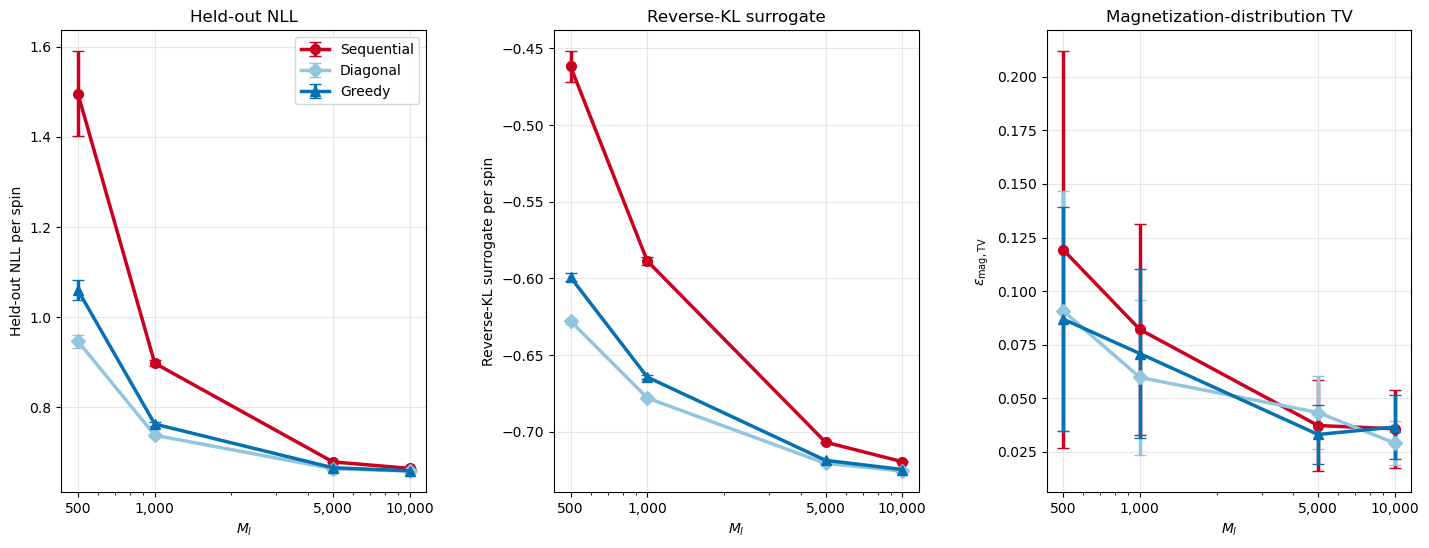

In [38]:
METRIC_LABELS = {
    "heldout_nll": r"Held-out NLL per spin",
    "reverse_kl_surrogate": r"Reverse-KL surrogate per spin",
    "magnetization_tv_error": r"$\varepsilon_{\mathrm{mag,TV}}$",
}

METRIC_TITLES = {
    "heldout_nll": "Held-out NLL",
    "reverse_kl_surrogate": "Reverse-KL surrogate",
    "magnetization_tv_error": "Magnetization-distribution TV",
}


def plot_error(metric, Ml_range, mean_errors, std_errors, models,
               ordering_keys, use_log_y=False, ax=None):

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    markers = ("o", "D", "^")
    colors = {
    "sequential": "#ca0020",
    "diagonal":   "#92c5de",
    "greedy":     "#0571b0",
}

    for marker, color, key in zip(markers, colors, ordering_keys):
        ax.errorbar(
            Ml_range,
            mean_errors[key][metric],
            yerr=std_errors[key][metric],
            marker=marker,
            color=colors[key],
            linewidth=2.5,
            markersize=7,
            capsize=4,
            label=models[key]["label"],
        )

    ax.set_xscale("log")

    if use_log_y:
        ax.set_yscale("log")

    ax.set_xticks(Ml_range)
    ax.set_xticklabels([f"{value:,}" for value in Ml_range])

    ax.set_xlabel(r"$M_l$")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_TITLES[metric])

    ax.grid(True, alpha=0.3)

    return ax


mean_errors = results["summary"]["mean"]
std_errors = results["summary"]["std"]

metrics_to_plot = (
    "heldout_nll",
    "reverse_kl_surrogate",
    "magnetization_tv_error",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, metric in zip(axes, metrics_to_plot):
    plot_error(
        metric,
        Ml_range,
        mean_errors,
        std_errors,
        models,
        ordering_keys,
        ax=ax,
    )

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.15,
    top=0.92,
    wspace=0.35,
)
axes[0].legend()
plt.show()

In [ ]:
# # To load neurise solution:
# checkpoint = torch.load("Results/neurise_global_beta_02.pt", map_location="cpu")

# ml = 5000
# key = "greedy"
# t = 2

# solution = checkpoint["solutions"][ml][key][t]

# network_global = make_mlp(
#     3 * N, hidden_dim, output_dim, num_hidden_layers
# )

# network_global.load_state_dict(solution["state_dict"])
# network_global.eval()

# gen_samples = generate_test_samples_global(
#     models[key]["seq"],
#     models[key]["parents"],
#     network_global,
#     Ms,
#     N,
#     rng=np.random.default_rng(123),
# )

In [4]:
from pathlib import Path
import numpy as np

blocks = []

for i in range(1, 11):
    path = f"../samples_10x10_SpinGlass_beta=08_task{i}.csv"
    block = np.loadtxt(path, delimiter=",").astype(np.int8)

    if block.shape != (20_000, 100):
        raise ValueError(f"task{i} has shape {block.shape}")

    blocks.append(block)

data_samples = np.vstack(blocks)

print(data_samples.shape)   # (200000, 100)

np.savetxt(
    "Samples_10x10_M=200K_Ferro_beta=08.csv",
    data_samples,
    fmt="%d",
    delimiter=",",
)

(200000, 100)


In [3]:
print(Path.cwd()) # Check current path

/Users/sbiswal/Documents/Code/Autoregressive Models
